### Fundamentos de Séries Temporais: Estruturas, Tendência e Sazonalidade


Neste material, abordaremos detalhadamente:
1. **Estruturas de Dados:** Cross-sectional vs Panel vs Séries Temporais
2. **Frequência e Sazonalidade**
3. **Tendência Determinística e Estocástica**
4. **Sazonalidade Aditiva vs Multiplicativa**

### 0. Configurações Iniciais e Reprodutibilidade

##### IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÕES GERAIS

In [ ]:
# Manipulação Numérica e Geração de Dados Matemáticos
import numpy as np
import pandas as pd

# Visualização Científica de Dados (Qualidade de Publicação)
import matplotlib.pyplot as plt
import seaborn as sns

# Pacotes de Estatística e Decomposição Clássica (Econometria)
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# Ferramentas para Processamento Orientado a Machine Learning
from sklearn.model_selection import TimeSeriesSplit

#### CONFIGURAÇÕES GLOBAIS DE REPRODUTIBILIDADE E LAYOUT

In [ ]:
# Fixando a semente estocástica para garantir reproducibilidade 
np.random.seed(42)

# Padronizando o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'font.family': 'sans-serif'
})

### 1. Estruturas de Dados e o Índice Temporal


*   **Corte Transversal (Cross-Sectional):** Constitui um *snapshot* (fotografia) independente e isolado. Refere-se à observação de múltiplos indivíduos ou entidades no mesmo e exato instante de tempo t. A hipótese de independência é frequentemente presumida.
*   **Dados em Painel (Panel Data):** Estrutura híbrida e profunda. Envolve a amostragem de múltiplos indivíduos em repetidos pontos ao longo do tempo. Permite controlar a heterogeneidade não observável por meio de Modelos de Efeitos Fixos e Aleatórios.
*   **Séries Temporais (Univariada / Multivariada):** O objeto deste estudo. Constitui-se de avaliações longitudinais exaustivas para capturar a evolução matemática de uma (ou mais) variáveis sobre uma entidade específica, orientada unicamente pela seta temporal.

#### 1.1 DADOS DE CORTE TRANSVERSAL (CROSS-SECTIONAL)
##### Observações tabulares de diferentes agentes num instante t_0

In [ ]:
n_individuos = 5
cross_sectional = pd.DataFrame({
    'ID_Agente': range(1, n_individuos + 1),
    'Rendimento_Mensal': np.round(np.random.normal(loc=5000, scale=800, size=n_individuos), 2),
    'Idade_Agente': np.round(np.random.normal(loc=35, scale=5, size=n_individuos), 0)
}).set_index('ID_Agente')

print("--- 1. Estrutura de Corte Transversal ---")
display(cross_sectional)



--- 1. Estrutura de Corte Transversal ---


,Rendimento_Mensal,Idade_Agente
ID_Agente,,
1,5397.37,34.0
2,4889.39,43.0
3,5518.15,39.0
4,6218.42,33.0
5,4812.68,38.0


#### 1.2 DADOS EM PAINEL (PANEL DATA)
##### Cada Agente (i) é investigado repetidamente em Períodos (t)


In [ ]:
n_periodos = 3

# Utiliza-se a abstração pd.MultiIndex para codificar a matriz de painel
multi_index = pd.MultiIndex.from_product(
    [range(1, n_individuos + 1), range(1, n_periodos + 1)],
    names=['Agente_i', 'Instante_t']
)

panel_data = pd.DataFrame({
    'Produtividade': np.round(np.random.normal(100, 15, size=n_individuos * n_periodos), 2),
}, index=multi_index)

print("\n--- 2. Estrutura de Dados em Painel Longitudinal (Head) ---")
display(panel_data.head(6))


--- 2. Estrutura de Dados em Painel Longitudinal (Head) ---


Produtividade
Agente_i Instante_t               
1        1                   93.05
         2                   93.01
         3                  103.63
2        1                   71.30
         2                   74.13
         3                   91.57

#### 1.3 SÉRIE TEMPORAL UNIVARIADA
##### O eixo é definido estritamente pelo delta cronológico contínuo


In [ ]:
# Conversão do índice temporal.
datas_mensais = pd.date_range(start='2023-01-01', periods=6, freq='MS')
serie_univariada = pd.DataFrame({
    'Inflacao_Geral': np.round(np.random.normal(0.5, 0.2, size=6), 3)
}, index=datas_mensais)

print("\n--- 3. Série Temporal Univariada (Indexação via Datetime) ---")
display(serie_univariada)


--- 3. Série Temporal Univariada (Indexação via Datetime) ---


,Inflacao_Geral
2023-01-01,0.522
2023-02-01,0.270
2023-03-01,0.575
2023-04-01,0.380
2023-05-01,0.442
2023-06-01,0.380


#### Interpretação Estatística e de Infraestrutura

> **Atenção:** Na modelagem da arquitetura de séries temporais usando Pandas e Statsmodels, a correta designação do eixo através do `DatetimeIndex` com uma *frequência preestabelecida* (como `'MS'` para *Month-Start*) não é um mero preciosismo. A vasta maioria dos métodos iterativos de cálculo para Autocorrelação, Decomposição de Fourier, e Ajustes Sazonais no ecossistema SARIMAX exige a extração da granularidade nativa a partir da *metadata* do índice (o sistema precisa saber se está regredindo em meses ou em microssegundos).

### 2. Relação Estrutural entre Frequência de Observação e Período Sazonal

O domínio do espaço em que as ocorrências são amostradas define a **Frequência** temporal. Ao tratarmos modelos paramétricos, utilizamos o parâmetro de período sazonal (frequentemente matematicamente denotado por m) para delinear o ponto temporal em que o ciclo estacional completo retorna à sua origem teórica.

Exemplos fundamentais de aplicação em dados e granularidades:
*   **Dados Mensais:** Possuem periodicidade estacional contundente fixada em m=12. A análise de inflação, varejo ou consumo habitacional opera quase exclusivamente neste âmbito.
*   **Dados Semanais:** A dinâmica se repete a cada semestre longo, adotando m=52.
*   **Dados Diários:** Exibem, quase sempre, fenômenos duplos: uma flutuação por dia útil com forte ciclo semanal (m=7) e uma oscilação macro ligada à amplitude anual (m≈365.25).
*   **Dados Horários (Monitoramento IoT, Demanda Elétrica):** Exigem altíssima granularidade. Notam-se picos sazonais que percorrem as horas do dia (m=24), envoltos em envelopes semanais complexos (m=168). Abordar ciclos de sazonalidade composta não deve ser realizado com ARIMA simplificado, exigindo algoritmos como TBATS que se baseiam em regressão espectral de fourier.

### 3. A Diferença Fundamental: Tendência Determinística vs. Tendência Estocástica

Uma intuição generalista assume "tendência" meramente como uma ascensão ou declínio linear observado pelo avaliador em um gráfico de pontos. Do ponto de vista puramente estatístico e epistemológico, o comportamento de uma série temporal ascendente é estruturalmente distinto dependendo da forma como o ruído residual afeta as observações sequenciais.

**3.1. Tendência Determinística:**
Caracteriza um processo analítico que repousa e avança independentemente sobre uma equação fundamental do tempo (t). O sinal de ruído (perturbação aleatória) afeta apenas o instante isolado. O choque dissipa-se imediatamente e a trajetória mestre permanece imutável.

**3.2. Tendência Estocástica (Random Walk with Drift):**
Consiste na espinha dorsal das análises financeiras e ativos da bolsa (processo com Raiz Unitária). Aqui, a variável incorpora absorções da memória infinita. O erro presente altera a base sistêmica do eixo para a perenidade do futuro. Séries com tendência estocástica são por definição processos integrados amplamente instáveis em termos de variância.

#### SIMULAÇÃO RIGOROSA: TENDÊNCIAS DETERMINÍSTICAS VS ESTOCÁSTICAS
##### O objetivo é visualizar os efeitos gerativos da raiz unitária

In [ ]:
N_amostras = 250
vetor_tempo_t = np.arange(1, N_amostras + 1)

np.random.seed(111)  # Fixando a semente para reproducibilidade
# Definimos um ruído branco clássico - gaussiano N(0, variância fixa)
ruido_gaussiano = np.random.normal(loc=0, scale=5, size=N_amostras)

# 1. Geração Determinística
coeficiente_beta0 = 15
coeficiente_beta1 = 0.35
# O ruído atinge Y_t isoladamente, mantendo a reta como âncora constante.
y_deterministico = coeficiente_beta0 + coeficiente_beta1 * vetor_tempo_t + ruido_gaussiano

# 2. Geração Estocástica (Passeio Aleatório / Random Walk)
y_estocastico = np.zeros(N_amostras)
parametro_drift = 0.35
y_estocastico[0] = coeficiente_beta0 + parametro_drift + ruido_gaussiano[0]

# Iterativamente: o choque anterior é absorvido estruturalmente como base do futuro
for k in range(1, N_amostras):
    y_estocastico[k] = y_estocastico[k-1] + parametro_drift + ruido_gaussiano[k]

#### VISUALIZAÇÃO MATEMÁTICA COMPARADA

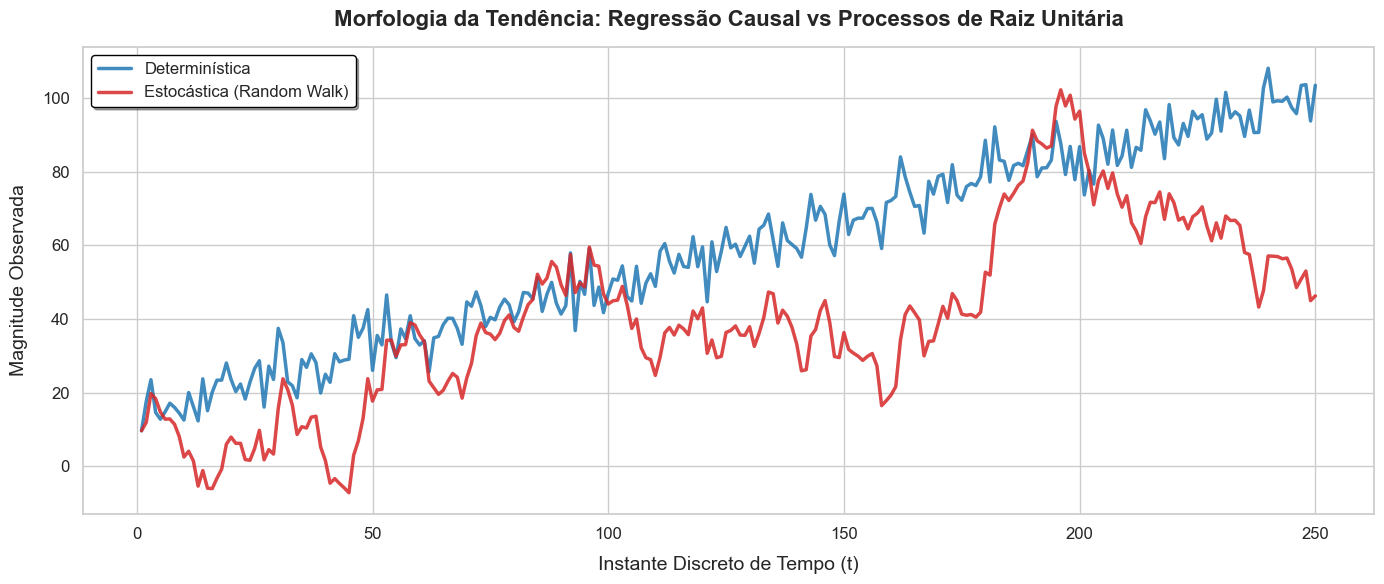

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(vetor_tempo_t, y_deterministico, label='Determinística', color='#1f77b4', linewidth=2.5, alpha=0.85)
ax.plot(vetor_tempo_t, y_estocastico, label='Estocástica (Random Walk)', color='#d62728', linewidth=2.5, alpha=0.85)

ax.set_title('Morfologia da Tendência: Regressão Causal vs Processos de Raiz Unitária', fontweight='bold', pad=15)
ax.set_xlabel('Instante Discreto de Tempo (t)', labelpad=10)
ax.set_ylabel('Magnitude Observada', labelpad=10)
ax.legend(loc='upper left', shadow=True, frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()

#### Interpretação Estatística e Consequências de Modelagem

*   **O Paradoxo Visual (Existe Tendência?):** Analiticamente, as duas trajetórias apresentam inclinação acentuada no decurso temporal. Visualmente os analistas inferem crescimento. Contudo, suas constituições fundamentais indicam que o método para extrair "estacionariedade" deve divergir violentamente.
*   **A Ocorrência do Erro Grave:** Um equívoco crônico provém do analista inexperiente tentar ajustar uma curva de mínimos quadrados ordinários (OLS linear) sobre o eixo cronológico nos dados em curva vermelha (Estocástica) e trabalhar os resíduos com a convicção plena de deter ruído branco. Essa conduta constitui a famosa e proibitiva **Regressão Espúria**.
*   **Diretrizes de Boas Práticas Estacionárias:** 
    *   Ao observar tendência determinística, impõe-se a técnica de remoção direta da base linear (**Detrending** via subtração da regressão).
    *   Ao lidarmos com a série estocástica, a eliminação teórica requer a obtenção do processo de **Diferenciação** de primeira ordem de defasagem (ex: Delta Y = Y(t) - Y(t-1)).

### 4. Sazonalidade: Compreensão Numérica das Componentes Aditivas e Multiplicativas


**4.1. Formulação do Modelo Aditivo:**
A flutuação conserva integralmente o mesmo espaçamento absoluto (constância de variância) independentemente do aumento absoluto do pilar principal da série.

**4.2. Formulação do Modelo Multiplicativo:**
O padrão da sazonalidade é intrinsecamente percentual e dependente da dimensão da tendência. Ocorre o fenômeno do cone expansivo. A flutuação entre picos e vales alarga seu alcance vertical paralelamente ao progresso global da tendência.

#### CONSTRUÇÃO DO CONE SAZONAL: ADITIVO X MULTIPLICATIVO

In [ ]:
pontos_cronologicos = np.arange(180)  # Equivalente a 15 anos estacionais mensais (m=12)

np.random.seed(42)  # Fixando a semente para reproducibilidade
# Componentes Formativas Lineares
base_tendencia = 80 + 0.65 * pontos_cronologicos

# 1. Geração da Matriz Aditiva
sazonalidade_aditiva = 18 * np.sin(2 * np.pi * pontos_cronologicos / 12)
ruido_aditivo = np.random.normal(0, 3, size=len(pontos_cronologicos))
ts_sinal_aditivo = base_tendencia + sazonalidade_aditiva + ruido_aditivo

# 2. Geração da Matriz Multiplicativa
sazonalidade_multiplicativa = 1 + 0.15 * np.sin(2 * np.pi * pontos_cronologicos / 12)
ruido_multiplicativo = 1 + 0.05 * np.random.normal(3, 2, size=len(pontos_cronologicos))
ts_sinal_multiplicativo = base_tendencia * sazonalidade_multiplicativa * ruido_multiplicativo

#### EXIBIÇÃO EM PAINEL COMPARATIVO DOS EFEITOS GERAIS

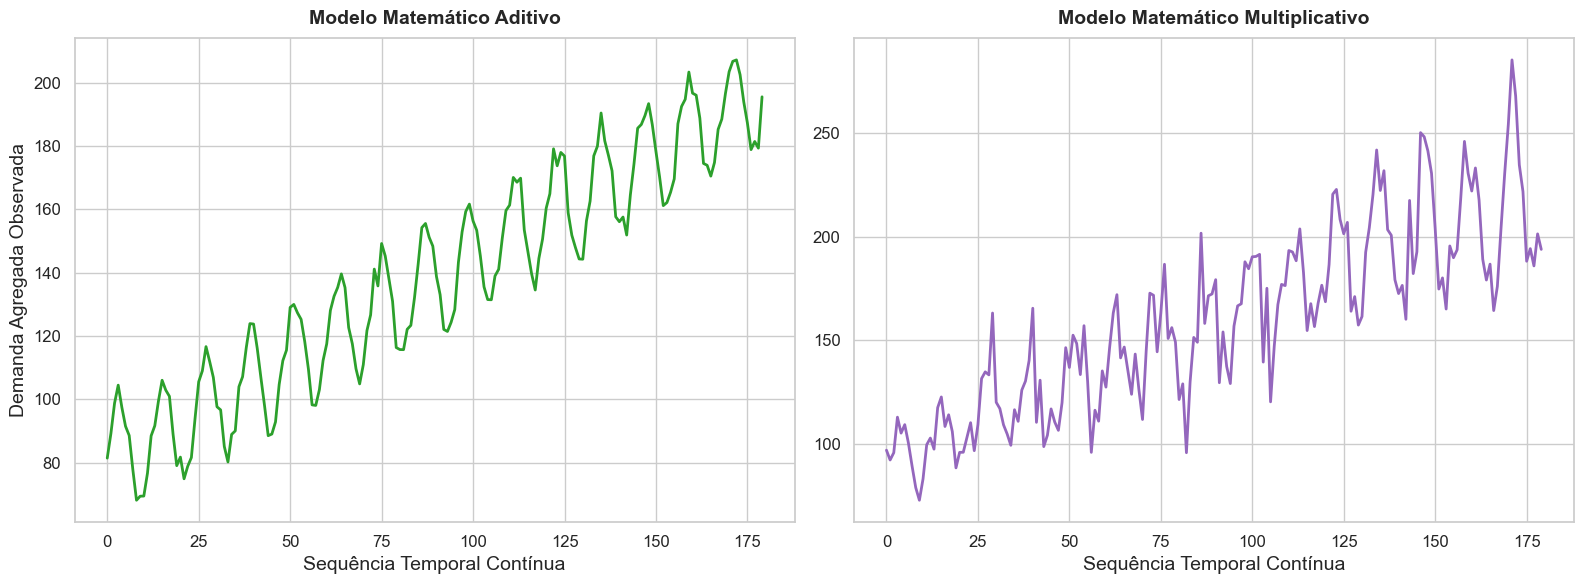

In [ ]:
fig, (painel_esq, painel_dir) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)


# Painel de Proporções Constantes (Aditivo)
painel_esq.plot(pontos_cronologicos, ts_sinal_aditivo, color='#2ca02c', linewidth=2)
painel_esq.set_title('Modelo Matemático Aditivo', fontweight='bold', fontsize=14, pad=10)
painel_esq.set_xlabel('Sequência Temporal Contínua')
painel_esq.set_ylabel('Demanda Agregada Observada')

# Painel de Dinâmica Expansiva (Multiplicativo)
painel_dir.plot(pontos_cronologicos, ts_sinal_multiplicativo, color='#9467bd', linewidth=2)
painel_dir.set_title('Modelo Matemático Multiplicativo', fontweight='bold', fontsize=14, pad=10)
painel_dir.set_xlabel('Sequência Temporal Contínua')

plt.tight_layout()
plt.show()

#### Interpretação das Perturbações Estruturais

*   **Interpretação e Amplitude:** Percebemos com enorme facilidade a natureza aditiva pelo envelope constante: independentemente se o processo da demanda geral estava em 100 ou em 200, a curva subia verticalmente a mesma proporção. Observando o modelo da direita, encontramos uma violenta mudança em leque e cone estendido, onde os picos sazonais aumentam de intensidade com o tempo da mesma forma que os vales também desabam muito mais com a elevação da série. A variância está intrinsecamente atrelada ao tempo e ao nível médio.
*   **A Ação Interventiva:** A manobra analítica mais difundida em econometria para enquadrar séries multiplicativas problemáticas em espectros aditivos dóceis é o uso da **Transformação Logarítmica**.